# Few-shot Learning

Test accuracy of the expand-and-sparsify classification pipeline as a function of the number of training exposures per category.

For each repetition, we incrementally add one randomly chosen frame (sequence exposure) per category and retrain $W_{\mathrm{out}}$ from scratch, measuring train & test accuracy at each step.

In [16]:
import numpy as np
from sklearn import metrics
from sklearn.decomposition import PCA
from math import comb
import matplotlib.pyplot as plt
from tools import load

## Parameters

In [17]:
n_hd = 10000
p_hd = 0.5
d = 0.5
p = 0.05
normalized = 'raw'
kernel = 'top'
n_times = 10

## Expansion helpers

In [18]:
def backward_diff_array(y, h, n):
    """n-th backward finite difference (zero-padded to preserve length)."""
    coeffs = np.array([(-1)**k * comb(n, k) for k in range(n + 1)])
    raw = np.convolve(y, coeffs, mode='valid') / h**n
    return np.concatenate([np.zeros(n), raw])


def expand_with_derivatives(data, h, max_order):
    if max_order == 0:
        return data.copy()
    derivs = []
    for order in range(1, max_order + 1):
        d = np.apply_along_axis(
            lambda col: backward_diff_array(col, h, order), axis=0, arr=data)
        derivs.append(d)
    return np.hstack([data] + derivs)


def build_152_expansion(sensor_data, h, ratio_pairs, diff_pairs):
    """8 raw + 8 d1 + 8 d2 + 64 diff + 64 ratio = 152 traces."""
    x_d12 = expand_with_derivatives(sensor_data, h, max_order=2)
    r64 = np.column_stack([sensor_data[:, i] / (sensor_data[:, j] + 1e-8)
                           for i, j in ratio_pairs[:64]])
    d64 = np.column_stack([sensor_data[:, i] - sensor_data[:, j]
                           for i, j in diff_pairs[:64]])
    return np.hstack([x_d12, d64, r64])

In [19]:
def expand_and_sparsify(x_dense, n_hd, p_hd, d, rng_proj):
    """Project to HD space and sparsify (top-k)."""
    k = int(d * n_hd)
    n_dense = x_dense.shape[1]
    W_hd = rng_proj.binomial(n=1, p=p_hd, size=(n_hd, n_dense))
    x_hd = x_dense @ W_hd.T
    ranks = np.argsort(np.argsort(-x_hd, axis=1), axis=1)
    z_hd = np.where(ranks < k, 1., 0.)
    return z_hd, k


def train_W_out(z_hd, labels, sample_mask, n_out, k, p, rng):
    """Hebbian training of W_out on the samples indicated by sample_mask."""
    W_out = np.zeros((n_out, z_hd.shape[1]))
    for i in np.where(sample_mask)[0]:
        if labels[i] != 0:
            active_idx = np.flatnonzero(z_hd[i])
            to_flip = active_idx[rng.random(active_idx.size) < p]
            W_out[int(labels[i]) - 1, to_flip] = 1. / k
    return W_out


def compute_accuracy(z_hd, W_out, true_labels, eval_mask):
    """Frame-level accuracy on the subset defined by eval_mask."""
    z_out = z_hd @ W_out.T
    preds = np.argmax(z_out, axis=1) + 1  # 1-indexed
    return metrics.accuracy_score(true_labels[eval_mask], preds[eval_mask])

## Single gases

In [20]:
# Load and expand
sensor_data, sequence, times_sec, sequence_sec = load('1_600_20', reduced=True)
h = np.median(np.diff(times_sec))
n_sensors = sensor_data.shape[1]
n_out_single = 3
n_train = 450

# Pair pools
rng_pairs = np.random.default_rng(0)
all_ordered_pairs = [(i, j) for i in range(n_sensors) for j in range(n_sensors) if i != j]
ratio_pairs = [all_ordered_pairs[i] for i in rng_pairs.permutation(len(all_ordered_pairs))]
diff_pairs  = [all_ordered_pairs[i] for i in rng_pairs.permutation(len(all_ordered_pairs))]

expanded_data = build_152_expansion(sensor_data, h, ratio_pairs, diff_pairs)

# Build frame-level labels for ALL sequences (for test evaluation)
frame_labels = np.zeros_like(times_sec)
for i in range(len(sequence_sec)):
    try:
        flag = (times_sec > sequence_sec[i]) & (times_sec < sequence_sec[i + 1])
    except IndexError:
        flag = (times_sec > sequence_sec[i])
    frame_labels[flag] = int(sequence[i][1])

# Train / test split by time
train_time_end = sequence_sec[n_train] if n_train < len(sequence_sec) else times_sec[-1] + 1
labeled_mask = frame_labels > 0
train_mask = labeled_mask & (times_sec < train_time_end)
test_mask  = labeled_mask & (times_sec >= train_time_end)

# Build per-sequence info: which samples belong to each training sequence, and their category
train_seq_info = []  # list of (category, sample_indices)
for i in range(n_train):
    cat = int(sequence[i][1])
    if cat == 0:
        continue
    try:
        flag = (times_sec > sequence_sec[i]) & (times_sec < sequence_sec[i + 1])
    except IndexError:
        flag = (times_sec > sequence_sec[i])
    indices = np.where(flag)[0]
    if len(indices) > 0:
        train_seq_info.append((cat, indices))

# Group sequences by category
categories_single = sorted(set(cat for cat, _ in train_seq_info))
seq_by_cat_single = {cat: [(cat2, idx) for cat2, idx in train_seq_info if cat2 == cat]
                     for cat in categories_single}

n_seqs_per_cat = min(len(v) for v in seq_by_cat_single.values())
print(f"Categories: {categories_single}")
print(f"Sequences per category: {[len(v) for v in seq_by_cat_single.values()]}")
print(f"Max picks (limited by smallest category): {n_seqs_per_cat}")

Categories: [1, 2, 3]
Sequences per category: [153, 149, 148]
Max picks (limited by smallest category): 148


In [21]:
# Few-shot learning loop
all_train_accs_single = []
all_test_accs_single = []

for rep in range(n_times):
    rng_rep = np.random.default_rng(rep)
    rng_proj = np.random.default_rng(rep * 1000)

    # Shuffle sequences within each category
    shuffled = {cat: [seqs[i] for i in rng_rep.permutation(len(seqs))]
                for cat, seqs in seq_by_cat_single.items()}

    # Normalization
    if normalized == 'whitened':
        idx_last = np.where(train_mask)[0][-1]
        train_mean = np.mean(expanded_data[:idx_last], axis=0)
        pca = PCA()
        pca.fit(expanded_data[:idx_last] - train_mean)
        var_mask = pca.explained_variance_ > 1e-12
        U = np.diag(1.0 / np.sqrt(pca.explained_variance_[var_mask])) @ pca.components_[var_mask]
        x_dense = (U @ (expanded_data - train_mean).T).T
    else:
        x_dense = expanded_data

    # Expand and sparsify
    z_hd, k = expand_and_sparsify(x_dense, n_hd, p_hd, d, rng_proj)

    train_accs = []
    test_accs = []

    # Incrementally add one frame per category
    cumulative_mask = np.zeros(len(times_sec), dtype=bool)

    for pick in range(n_seqs_per_cat):
        # Add one new sequence from each category
        for cat in categories_single:
            _, indices = shuffled[cat][pick]
            cumulative_mask[indices] = True

        # Train W_out on cumulative selection
        rng_train = np.random.default_rng(rep * 10000 + pick)
        W_out = train_W_out(z_hd, frame_labels, cumulative_mask, n_out_single, k, p, rng_train)

        # Evaluate
        train_acc = compute_accuracy(z_hd, W_out, frame_labels, cumulative_mask)
        test_acc  = compute_accuracy(z_hd, W_out, frame_labels, test_mask)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

    all_train_accs_single.append(train_accs)
    all_test_accs_single.append(test_accs)
    print(f"Rep {rep}: final test acc = {test_accs[-1]:.4f}")

all_train_accs_single = np.array(all_train_accs_single)  # (n_times, n_picks)
all_test_accs_single  = np.array(all_test_accs_single)

Rep 0: final test acc = 0.6549
Rep 1: final test acc = 0.6380
Rep 2: final test acc = 0.5780
Rep 3: final test acc = 0.6401
Rep 4: final test acc = 0.7352
Rep 5: final test acc = 0.6419
Rep 6: final test acc = 0.6573
Rep 7: final test acc = 0.5886
Rep 8: final test acc = 0.5896
Rep 9: final test acc = 0.6107


## Binary mixtures

In [22]:
# Load train and test
train_data_raw, train_sequence, train_times_sec, train_sequence_sec = load('mix_100_20_1', reduced=True)
test_data_raw, test_sequence, test_times_sec, test_sequence_sec = load('mix_50_20_1', reduced=True)

h_train = np.median(np.diff(train_times_sec))
h_test  = np.median(np.diff(test_times_sec))
n_sensors_b = train_data_raw.shape[1]
n_out_binary = 6

# Pair pools (same seed)
rng_pairs_b = np.random.default_rng(0)
all_ordered_pairs_b = [(i, j) for i in range(n_sensors_b) for j in range(n_sensors_b) if i != j]
ratio_pairs_b = [all_ordered_pairs_b[i] for i in rng_pairs_b.permutation(len(all_ordered_pairs_b))]
diff_pairs_b  = [all_ordered_pairs_b[i] for i in rng_pairs_b.permutation(len(all_ordered_pairs_b))]

train_expanded = build_152_expansion(train_data_raw, h_train, ratio_pairs_b, diff_pairs_b)
test_expanded  = build_152_expansion(test_data_raw, h_test, ratio_pairs_b, diff_pairs_b)

# Build labels
train_labels_b = np.zeros_like(train_times_sec)
for i in range(len(train_sequence_sec)):
    try:
        flag = (train_times_sec > train_sequence_sec[i]) & (train_times_sec < train_sequence_sec[i + 1])
    except IndexError:
        flag = (train_times_sec > train_sequence_sec[i])
    train_labels_b[flag] = int(train_sequence[i][1])

test_labels_b = np.zeros_like(test_times_sec)
for i in range(len(test_sequence_sec)):
    try:
        flag = (test_times_sec > test_sequence_sec[i]) & (test_times_sec < test_sequence_sec[i + 1])
    except IndexError:
        flag = (test_times_sec > test_sequence_sec[i])
    test_labels_b[flag] = int(test_sequence[i][1])

train_labeled_b = train_labels_b > 0
test_labeled_b  = test_labels_b > 0

# Per-sequence info for training data
train_seq_info_b = []
for i in range(len(train_sequence_sec)):
    cat = int(train_sequence[i][1])
    if cat == 0:
        continue
    try:
        flag = (train_times_sec > train_sequence_sec[i]) & (train_times_sec < train_sequence_sec[i + 1])
    except IndexError:
        flag = (train_times_sec > train_sequence_sec[i])
    indices = np.where(flag)[0]
    if len(indices) > 0:
        train_seq_info_b.append((cat, indices))

categories_binary = sorted(set(cat for cat, _ in train_seq_info_b))
seq_by_cat_binary = {cat: [(cat2, idx) for cat2, idx in train_seq_info_b if cat2 == cat]
                     for cat in categories_binary}

n_seqs_per_cat_b = min(len(v) for v in seq_by_cat_binary.values())
print(f"Categories: {categories_binary}")
print(f"Sequences per category: {[len(v) for v in seq_by_cat_binary.values()]}")
print(f"Max picks: {n_seqs_per_cat_b}")

Categories: [1, 2, 3, 4, 5, 6]
Sequences per category: [100, 100, 100, 100, 100, 100]
Max picks: 100


In [23]:
# Few-shot learning loop
all_train_accs_binary = []
all_test_accs_binary = []

for rep in range(n_times):
    rng_rep = np.random.default_rng(rep)
    rng_proj = np.random.default_rng(rep * 1000)

    shuffled = {cat: [seqs[i] for i in rng_rep.permutation(len(seqs))]
                for cat, seqs in seq_by_cat_binary.items()}

    # Normalization (fit on train, apply to both)
    if normalized == 'whitened':
        train_mean = np.mean(train_expanded, axis=0)
        pca = PCA()
        pca.fit(train_expanded - train_mean)
        var_mask = pca.explained_variance_ > 1e-12
        U = np.diag(1.0 / np.sqrt(pca.explained_variance_[var_mask])) @ pca.components_[var_mask]
        x_train = (U @ (train_expanded - train_mean).T).T
        x_test  = (U @ (test_expanded  - train_mean).T).T
    else:
        x_train = train_expanded
        x_test  = test_expanded

    # Expand and sparsify (shared W_hd)
    n_dense = x_train.shape[1]
    k = int(d * n_hd)
    W_hd = rng_proj.binomial(n=1, p=p_hd, size=(n_hd, n_dense))

    x_hd_train = x_train @ W_hd.T
    ranks = np.argsort(np.argsort(-x_hd_train, axis=1), axis=1)
    z_hd_train = np.where(ranks < k, 1., 0.)

    x_hd_test = x_test @ W_hd.T
    ranks = np.argsort(np.argsort(-x_hd_test, axis=1), axis=1)
    z_hd_test = np.where(ranks < k, 1., 0.)

    train_accs = []
    test_accs = []

    cumulative_mask = np.zeros(len(train_times_sec), dtype=bool)

    for pick in range(n_seqs_per_cat_b):
        for cat in categories_binary:
            _, indices = shuffled[cat][pick]
            cumulative_mask[indices] = True

        rng_train = np.random.default_rng(rep * 10000 + pick)
        W_out = train_W_out(z_hd_train, train_labels_b, cumulative_mask,
                            n_out_binary, k, p, rng_train)

        # Train accuracy on selected frames
        z_out_train = z_hd_train @ W_out.T
        train_preds = np.argmax(z_out_train, axis=1) + 1
        train_acc = metrics.accuracy_score(
            train_labels_b[cumulative_mask], train_preds[cumulative_mask])

        # Test accuracy
        z_out_test = z_hd_test @ W_out.T
        test_preds = np.argmax(z_out_test, axis=1) + 1
        test_acc = metrics.accuracy_score(
            test_labels_b[test_labeled_b], test_preds[test_labeled_b])

        train_accs.append(train_acc)
        test_accs.append(test_acc)

    all_train_accs_binary.append(train_accs)
    all_test_accs_binary.append(test_accs)
    print(f"Rep {rep}: final test acc = {test_accs[-1]:.4f}")

all_train_accs_binary = np.array(all_train_accs_binary)
all_test_accs_binary  = np.array(all_test_accs_binary)

Rep 0: final test acc = 0.3292
Rep 1: final test acc = 0.3270
Rep 2: final test acc = 0.3473
Rep 3: final test acc = 0.3299
Rep 4: final test acc = 0.3573
Rep 5: final test acc = 0.3480
Rep 6: final test acc = 0.3456
Rep 7: final test acc = 0.3291
Rep 8: final test acc = 0.3519
Rep 9: final test acc = 0.3243


## Results

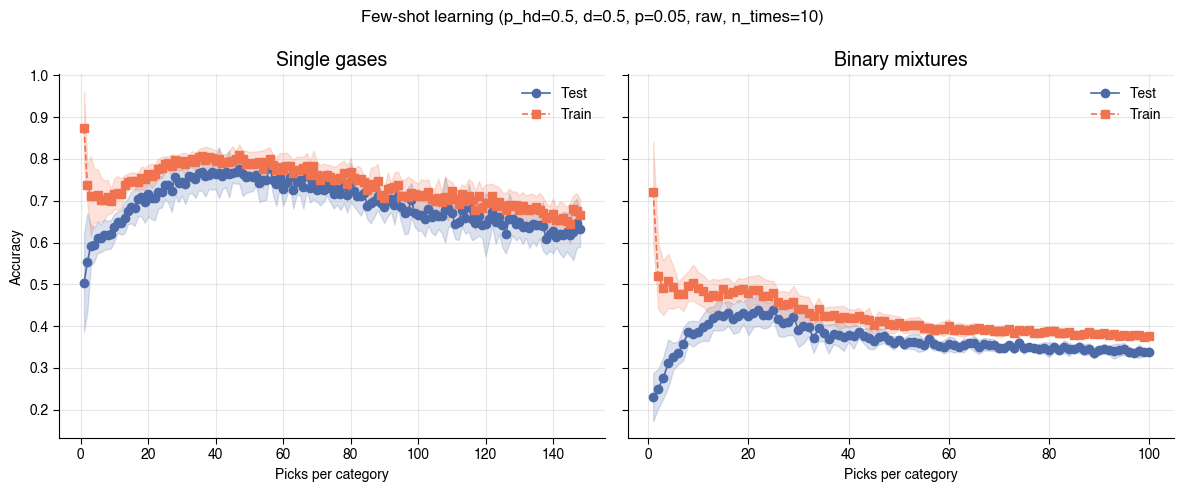

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# --- Single gases ---
ax = axes[0]
picks = np.arange(1, all_test_accs_single.shape[1] + 1)
mean_test = all_test_accs_single.mean(axis=0)
std_test  = all_test_accs_single.std(axis=0)
mean_train = all_train_accs_single.mean(axis=0)
std_train  = all_train_accs_single.std(axis=0)

ax.plot(picks, mean_test, 'o-', label='Test', color='C0')
ax.fill_between(picks, mean_test - std_test, mean_test + std_test, alpha=0.2, color='C0')
ax.plot(picks, mean_train, 's--', label='Train', color='C1')
ax.fill_between(picks, mean_train - std_train, mean_train + std_train, alpha=0.2, color='C1')
ax.set_xlabel('Picks per category')
ax.set_ylabel('Accuracy')
ax.set_title('Single gases')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Binary mixtures ---
ax = axes[1]
picks_b = np.arange(1, all_test_accs_binary.shape[1] + 1)
mean_test_b = all_test_accs_binary.mean(axis=0)
std_test_b  = all_test_accs_binary.std(axis=0)
mean_train_b = all_train_accs_binary.mean(axis=0)
std_train_b  = all_train_accs_binary.std(axis=0)

ax.plot(picks_b, mean_test_b, 'o-', label='Test', color='C0')
ax.fill_between(picks_b, mean_test_b - std_test_b, mean_test_b + std_test_b, alpha=0.2, color='C0')
ax.plot(picks_b, mean_train_b, 's--', label='Train', color='C1')
ax.fill_between(picks_b, mean_train_b - std_train_b, mean_train_b + std_train_b, alpha=0.2, color='C1')
ax.set_xlabel('Picks per category')
ax.set_title('Binary mixtures')
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle(f'Few-shot learning (p_hd={p_hd}, d={d}, p={p}, {normalized}, n_times={n_times})',
             fontsize=12)
fig.tight_layout()
plt.show()